## chatbot with memory

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

In [7]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장  # 튜플형으로 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool] 
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 바인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

### 메모리 저장소

In [ ]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()  # 상태 체크포인트를 RAM에 저장하는 객체

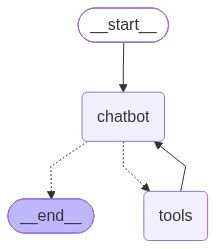

In [6]:
# langgraph.prebuilt 모듈의 ToolNode와 tools_condition 함수 사용한 빌더
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')   # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=memory)  # 체크포인터를 포함하여 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [12]:
from pprint import pprint

user1_config = {'configurable': {'thread_id': 'user1'}}

state = {'messages': [('human', '안녕, 나는 cap이라고 해. 만나서 반가워.')]} 

response = graph.invoke(state, user1_config)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='안녕, 나는 cap이라고 해. 만나서 반가워.', additional_kwargs={}, response_metadata={}, id='d91f7eac-c879-4e19-92fd-d5ed1e85406f'),
              AIMessage(content='안녕 cap! 만나서 반가워요.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1282, 'total_tokens': 1306, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrhGYmCMjqHWhNaq9yqRrBSw9nzX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-73f2-7a10-9dce-12f167af97c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [13]:
state = {'messages': [('human', '내 이름이 뭐라고 했지? 요즘 기억이 안 나네 .. ')]} 

response = graph.invoke(state, user1_config)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='안녕, 나는 cap이라고 해. 만나서 반가워.', additional_kwargs={}, response_metadata={}, id='d91f7eac-c879-4e19-92fd-d5ed1e85406f'),
              AIMessage(content='안녕 cap! 만나서 반가워요.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1282, 'total_tokens': 1306, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrhGYmCMjqHWhNaq9yqRrBSw9nzX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-73f2-7a10-9dce-12f167af97c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1

In [14]:
user2_config = {'configurable': {'thread_id': 'user2'}}  # 스레드 id 바꾸면 이전 다른 스레드 id 기억 없음

state = {'messages': [('human', '안녕, 내 이름이 뭐라고 했지?')]} 

response = graph.invoke(state, user2_config)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='안녕, 내 이름이 뭐라고 했지?', additional_kwargs={}, response_metadata={}, id='6dc64e88-38e3-4826-aee5-9903778a557f'),
              AIMessage(content='안녕하세요! 아직 제게 이름을 알려주신 적이 없어서 모르겠어요.  \n원하시면 지금 알려주세요—그 이름으로 불러드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 1279, 'total_tokens': 1319, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrjPPclsxAV9RsYaIlTWFTAklUOi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06527-7fb5-7ca0-bf5e-923a4a5cd109-0', tool_calls=[], invalid_tool_calls=[], usa

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [15]:
# 체크포인터에 저장된 특정 thread_id의 대화 스냅샷 조회
snapshot = graph.get_state(user1_config)
print(snapshot)
print(snapshot.values['messages'])

StateSnapshot(values={'messages': [HumanMessage(content='안녕, 나는 cap이라고 해. 만나서 반가워.', additional_kwargs={}, response_metadata={}, id='d91f7eac-c879-4e19-92fd-d5ed1e85406f'), AIMessage(content='안녕 cap! 만나서 반가워요.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1282, 'total_tokens': 1306, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrhGYmCMjqHWhNaq9yqRrBSw9nzX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-73f2-7a10-9dce-12f167af97c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

In [ ]:
all_snapshot = memory.list({})  # memory에 저장된 전체 스냅샷 리스트 조회

for snapshot in all_snapshot:
    print(f"Thread ID: {snapshot.config['configurable']['thread_id']}")  # thread_id
    if 'messages' in snapshot.checkpoint['channel_values']:  # message 채널 값 존재 확인
        pprint(snapshot.checkpoint['channel_values']['messages'])  # 해당 스냅샷의 누적 messages 출력
    else:
        print('스냅샷에 저장할 메시지가 없습니다.')
    print()

Thread ID: user1
[HumanMessage(content='안녕, 나는 cap이라고 해. 만나서 반가워.', additional_kwargs={}, response_metadata={}, id='d91f7eac-c879-4e19-92fd-d5ed1e85406f'),
 AIMessage(content='안녕 cap! 만나서 반가워요.  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1282, 'total_tokens': 1306, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrhGYmCMjqHWhNaq9yqRrBSw9nzX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-73f2-7a10-9dce-12f167af97c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1282, 'out

memory상에 대화간 입력했던 내용들이 스냅샷으로 저장되고,   
이 스냅샷에서 최종 대화내용 중 실제 대화만 꺼내어 영속적인 DB에 저장하여 유지한다